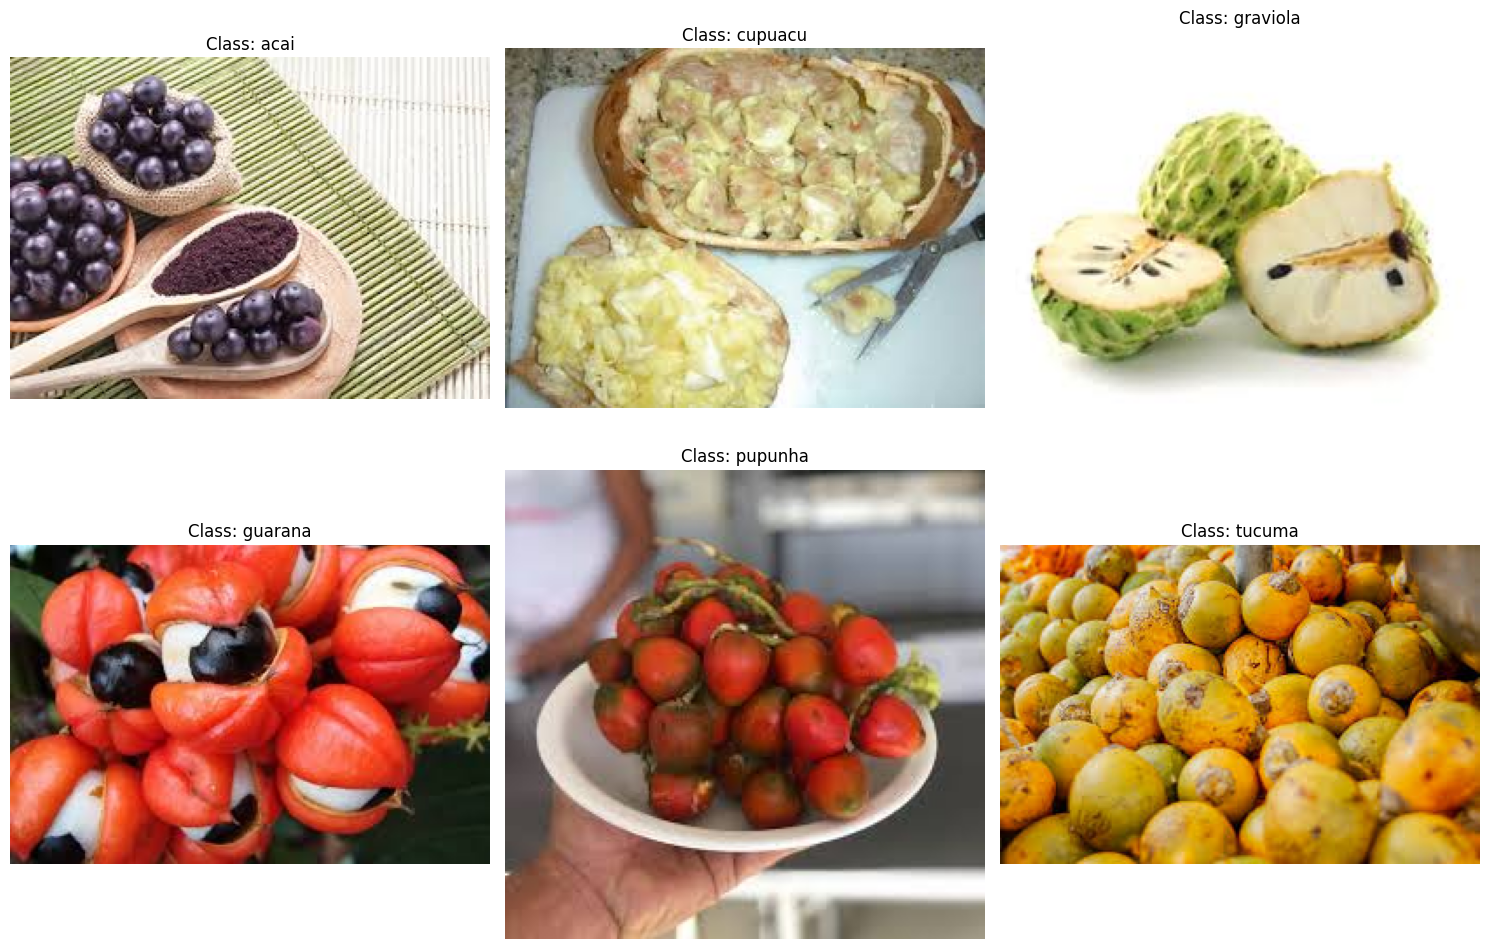

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 985ms/step - accuracy: 0.1806 - loss: 2.0273 - val_accuracy: 0.1667 - val_loss: 1.8024
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 596ms/step - accuracy: 0.3056 - loss: 1.7631 - val_accuracy: 0.0556 - val_loss: 1.9104
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 901ms/step - accuracy: 0.2222 - loss: 1.7470 - val_accuracy: 0.2222 - val_loss: 1.7992
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 597ms/step - accuracy: 0.3611 - loss: 1.5626 - val_accuracy: 0.1111 - val_loss: 1.9378
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4583 - loss: 1.3267 - val_accuracy: 0.2222 - val_loss: 1.9774
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 606ms/step - accuracy: 0.5694 - loss: 1.1200 - val_accuracy: 0.3333 - val_loss: 1.8536
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 904ms/step - accuracy: 0.6528 -

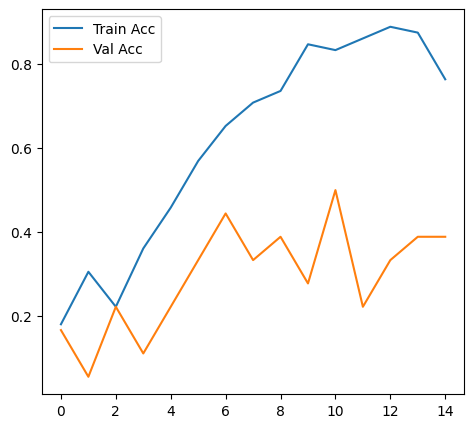

/tmp/ipykernel_2714/1369347451.py:80: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 940ms/step - accuracy: 0.1250 - loss: 3.0508 - val_accuracy: 0.1667 - val_loss: 2.8289
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step - accuracy: 0.1111 - loss: 3.0311 - val_accuracy: 0.1667 - val_loss: 2.7301
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 626ms/step - accuracy: 0.1250 - loss: 3.0209 - val_accuracy: 0.1111 - val_loss: 2.6484
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 324ms/step - accuracy: 0.1389 - loss: 2.8017 - val_accuracy: 0.1111 - val_loss: 2.5621
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 448ms/step - accuracy: 0.0972 - loss: 2.7513 - val_accuracy: 0.0556 - val_loss: 2.5000
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 317ms/step - accuracy: 0.1111 - loss: 2.4607 - val_accuracy: 0.0000e+00 - val_loss: 2.4388
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 314ms/step - accuracy: 0.1528 - loss: 2.5421 - val_accuracy: 0.0000e+00 - val_loss: 2.3802
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step - accuracy: 0.1111 - loss: 2.4273 - val_accuracy: 0.0000e+00

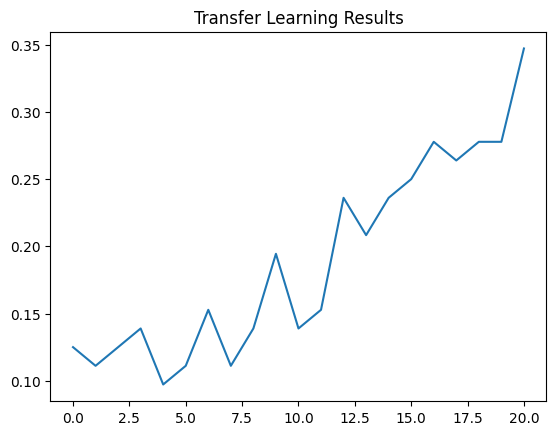

In [5]:
import zipfile
import os
import random
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# --- WORKSHEET 5 ---
# 1. Extraction and Directory Setup
zip_path = '/content/FruitinAmazon.zip'
extract_path = '/content/fruit_dataset'
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

train_dir = os.path.join(extract_path, 'FruitinAmazon/train')
test_dir = os.path.join(extract_path, 'FruitinAmazon/test')

# 2. Data Inspection and Visualization
classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
plt.figure(figsize=(15, 10))
for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)
    random_image = random.choice(images)
    img_path = os.path.join(class_path, random_image)
    img = mpimg.imread(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {class_name}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# 3. Data Loading & Preprocessing
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
train_ds = tf.keras.utils.image_dataset_from_directory(train_dir, validation_split=0.2, subset="training", seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE)
val_ds = tf.keras.utils.image_dataset_from_directory(train_dir, validation_split=0.2, subset="validation", seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE)
test_ds = tf.keras.utils.image_dataset_from_directory(test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE)

# 4. Configure Dataset for Performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 5. CNN Architecture
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Rescaling(1./255),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(len(classes), activation='softmax')
])

# 6. Compilation and Training
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_ds, validation_data=val_ds, epochs=15)

# 7. Custom Model Evaluation and Visualization
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.show()

# --- WORKSHEET 6 ---
# 8. Load Pre-trained Base Model
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base_model.trainable = False

# 9. Data Augmentation and Preprocessing Layers
data_augmentation = tf.keras.Sequential([layers.RandomFlip("horizontal"), layers.RandomRotation(0.2), layers.RandomZoom(0.2)])
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# 10. Building the Transfer Learning Model
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(classes), activation='softmax')(x)
transfer_model = tf.keras.Model(inputs, outputs)

# 11. Initial Model Compilation and Training
transfer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
initial_epochs = 10
history_transfer = transfer_model.fit(train_ds, epochs=initial_epochs, validation_data=val_ds)

# 12. Unfreezing Base Model for Fine-tuning
base_model.trainable = True
transfer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 13. Fine-tuning the Model
total_epochs = initial_epochs + 10
history_fine_tune = transfer_model.fit(train_ds, epochs=total_epochs, initial_epoch=history_transfer.epoch[-1], validation_data=val_ds)

# 14. Final Evaluation and Results Visualization
transfer_model.evaluate(test_ds)
acc = history_transfer.history['accuracy'] + history_fine_tune.history['accuracy']
plt.plot(acc, label='Accuracy')
plt.title('Transfer Learning Results')
plt.show()